# MLP Back-Programation

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## 1. Avaliando Pesos Iniciais e Funções de ativação

In [22]:
# load do dataset
df = pd.read_excel("Dry_Bean_Dataset.xlsx")
x =  df.drop("Class", axis=1)
y = df["Class"]

tabela_classes = (
    df["Class"]
    .value_counts()
    .reset_index()
)

tabela_classes.columns = ["Classe", "Quantidade"]

print(tabela_classes)

# Categoria -> numero

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Divisão do dataser

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  

#Nomalização

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


     Classe  Quantidade
0  DERMASON        3546
1      SIRA        2636
2     SEKER        2027
3     HOROZ        1928
4      CALI        1630
5  BARBUNYA        1322
6    BOMBAY         522


In [12]:
#Rede Neural

def mlp():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(16,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(7, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [21]:
#Treinamento com pesos diferentes
seeds = [1, 2, 3, 4, 5]

historicos = []

for seed in seeds:

    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    model = mlp()

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    loss_final = history.history['loss'][-1]
    acc_final = history.history['accuracy'][-1]

    historicos.append(history.history)

resultados = []

for i, h in enumerate(historicos):

    resultados.append({
        'Seed': seeds[i],
        'Loss Final': h['loss'][-1],
        'Accuracy Final': h['accuracy'][-1]
    })

df_resultados = pd.DataFrame(resultados)

print(df_resultados)

   Seed  Loss Final  Accuracy Final
0     1    0.163097        0.937821
1     2    0.161734        0.938648
2     3    0.162260        0.936719
3     4    0.160708        0.937913
4     5    0.166993        0.938464


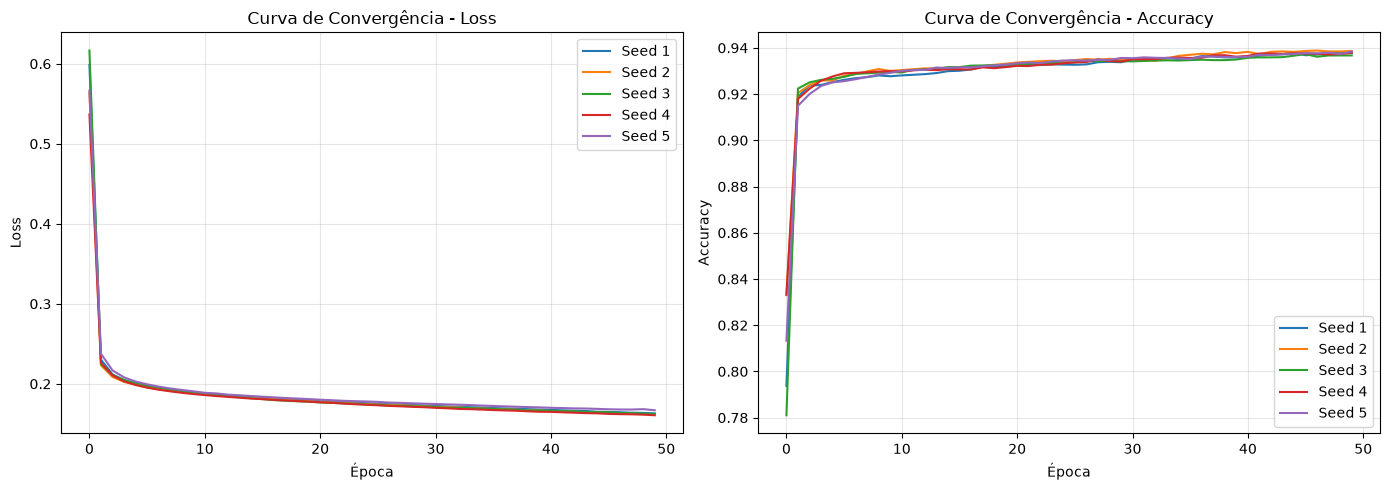

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for i, h in enumerate(historicos):
    ax1.plot(
        h['loss'],
        label=f'Seed {seeds[i]}'
    )

ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Curva de Convergência - Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
for i, h in enumerate(historicos):
    ax2.plot(
        h['accuracy'],
        label=f'Seed {seeds[i]}'
    )

ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_title('Curva de Convergência - Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()